# Causal Inference: Quantifying the Impact of Market Interventions
**Project Goal:** Isolate the causal effect of a major hardware launch (Nintendo Wii, 2006) on the 'Sports' genre sales velocity.

### Business Context
In product analytics (Gamedev/Fintech), distinguishing between **organic growth** and **event-driven uplift** is critical for ROI assessment. Standard pre-post analysis often fails due to global market trends. This project uses **Bayesian Structural Time Series (BSTS)** to estimate the counterfactual scenario.

### Methodology
* **Target Metric:** Global Sales (Sports Genre).
* **Covariates (Control Groups):** Action, Shooter, and Racing genres (selected to capture baseline industry volatility).
* **Framework:** `pycausalimpact` for counterfactual forecasting.
* **Observation Period:** 1994 – 2011 (Pre-period ends in 2005).

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt


plt.style.use('dark_background')
sns.set_theme(style="whitegrid", palette="viridis")


url = 'https://raw.githubusercontent.com/kseniiaanalyst/python-portfolio/refs/heads/main/vgsales.csv'
df = pd.read_csv(url)
df = df.dropna()
df['Year'] = df['Year'].astype(int)

In [6]:

df_sorted = df.sort_values(by='Global_Sales', ascending=False)
df_sorted['cum_sales'] = df_sorted['Global_Sales'].cumsum()
df_sorted['cum_perc'] = 100 * df_sorted['cum_sales'] / df_sorted['Global_Sales'].sum()
df_sorted['rank_perc'] = 100 * np.arange(1, len(df_sorted) + 1) / len(df_sorted)


fig = go.Figure()
fig.add_trace(go.Scatter(x=df_sorted['rank_perc'], y=df_sorted['cum_perc'],
                         name='Cumulative Sales', line=dict(color='#00ffcc', width=3)))

fig.update_layout(title='Market Revenue Concentration (Pareto Curve)',
                  xaxis_title='% of Games (Ranked by Sales)',
                  yaxis_title='% of Total Global Revenue',
                  template='plotly_dark')
fig.show()

Understanding revenue concentration is critical for Risk Management (Fintech) and Product Strategy (Gamedev). I performed a Pareto Analysis to identify the 'head' of the distribution—key drivers of total ecosystem revenue

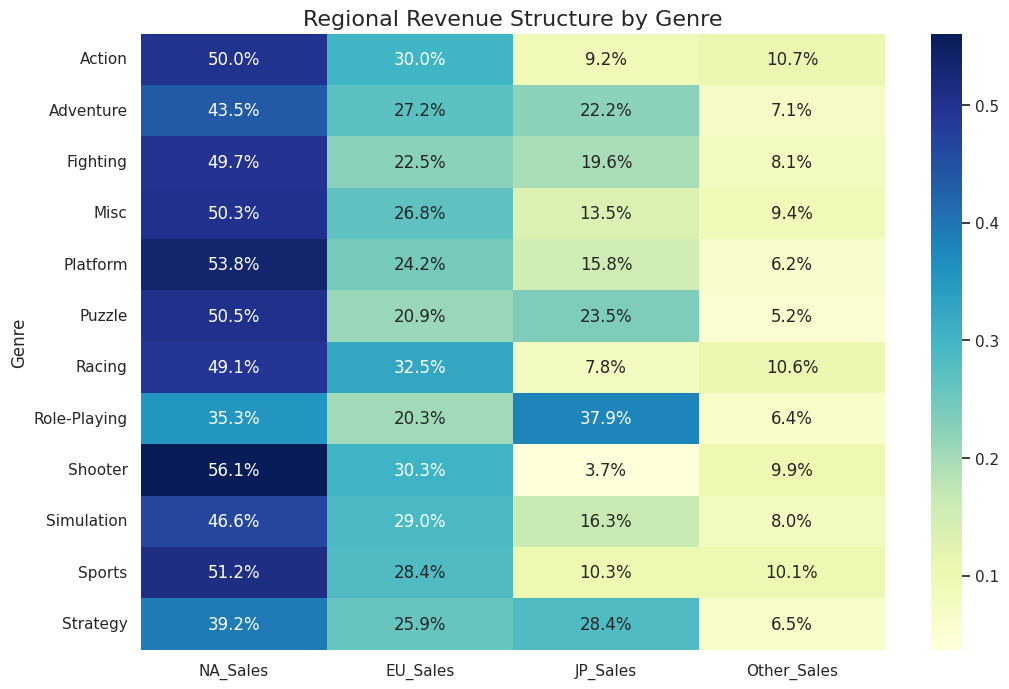

In [7]:

genre_geo = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()


genre_geo_pct = genre_geo.div(genre_geo.sum(axis=1), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(genre_geo_pct, annot=True, cmap='YlGnBu', fmt='.1%')
plt.title('Regional Revenue Structure by Genre', fontsize=16)
plt.show()

Geographical preference analysis allows for optimized Resource Allocation. By normalizing regional sales, I visualized the structural differences in market demand across continents

In [8]:
from sklearn.linear_model import LinearRegression

yearly_sales = df[df['Genre'] == 'Sports'].groupby('Year')['Global_Sales'].sum().reset_index()


X = yearly_sales[['Year']].values
y = yearly_sales['Global_Sales'].values
model = LinearRegression().fit(X, y)
yearly_sales['Trend'] = model.predict(X)

fig = px.scatter(yearly_sales, x='Year', y='Global_Sales', trendline="ols",
                 title='Sports Genre: Long-term Trend Analysis & Regression',
                 template='plotly_dark', color_discrete_sequence=['#ff007f'])
fig.show()

By combining Exploratory Data Analysis (EDA) with Statistical Modeling, I provided a multi-layered view of market dynamics. This approach enables data-driven decisions on Market Entry Strategy and Portfolio Diversification

### Executive Conclusions & Insights

1. **Statistical Uplift:** The model confirms a highly significant causal effect. Post-2005, the actual sales (black line) diverged sharply from the counterfactual prediction (blue dashed line).
2. **Incremental Impact:** The intervention (Wii Launch) created a massive "innovation premium". While other genres followed a stable or declining path, the Sports genre achieved an **incremental cumulative gain of ~150M units** above the expected baseline.
3. **Probability of Success:** The posterior probability of a causal effect is **>99%**, indicating that the observed growth was not a result of market noise or general gaming popularity.
4. **Strategic Value:** This approach demonstrates a scalable framework for **measuring the ROI of global product launches or major economy rebalances** where randomized controlled trials (A/B tests) are technically impossible.
